Here, we compare Logistic Regression, XGBoost, SVC, and RandomForest's performance via nestedCV.

# Imports

In [18]:
import pandas as pd
import numpy as np

# Get and Format Data

In [19]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [20]:
amazon_train_sets = [prepare_data(pd.read_csv(f"datasets/large/amazon_train_{year}_large.csv"), year) for year in range(2021, 2024)]
amazon_train = pd.concat(amazon_train_sets, axis=0)

train_set = amazon_train
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year').reset_index()
print(train_set.head())
print(train_set.groupby('year')['class'].value_counts())

   index system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
0   5510     2_2528_0        0.048014  0.405002         0.022265   0.257981   
1   3735      2_743_0        0.005098  0.336033         0.006462   0.202022   
2   3411      2_417_0        0.004592  0.344054         0.015524   0.231916   
3   5890     2_2912_0       -0.005589  0.311577        -0.001408   0.188605   
4   5567     2_2585_0       -0.010042  0.380244        -0.022120   0.228192   

   NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  ...  NDVI_lag1  \
0         0.053922   0.462311            -178.5      8107.0  ...   0.408390   
1         0.002212   0.385369             -44.5      8122.5  ...   0.383157   
2        -0.001532   0.384680              57.0      8041.0  ...   0.386212   
3        -0.004155   0.360151            -104.0      7969.0  ...   0.364306   
4        -0.010479   0.438665             212.0      8302.0  ...   0.449145   

   SR_B4_lag1  SR_B5_lag1  SR_B6_lag1  SR_B7_lag1 

# Feature Selection

In [21]:
# select all feature columns except metadata/target columns
exclude_cols = {'index', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'}
all_features = [c for c in train_set.columns if c not in exclude_cols]
# drop columns ending with "delta_lag1"

In [22]:
X_train = train_set[all_features]
y_train = train_set['class']
print(X_train.columns)

Index(['NBR_delta_lag4', 'NBR_lag4', 'NDMI_delta_lag4', 'NDMI_lag4',
       'NDVI_delta_lag4', 'NDVI_lag4', 'SR_B4_delta_lag4', 'SR_B4_lag4',
       'SR_B5_delta_lag4', 'SR_B5_lag4', 'SR_B6_delta_lag4', 'SR_B6_lag4',
       'SR_B7_delta_lag4', 'SR_B7_lag4', 'NBR_delta_lag3', 'NBR_lag3',
       'NDMI_delta_lag3', 'NDMI_lag3', 'NDVI_delta_lag3', 'NDVI_lag3',
       'SR_B4_delta_lag3', 'SR_B4_lag3', 'SR_B5_delta_lag3', 'SR_B5_lag3',
       'SR_B6_delta_lag3', 'SR_B6_lag3', 'SR_B7_delta_lag3', 'SR_B7_lag3',
       'NBR_delta_lag2', 'NBR_lag2', 'NDMI_delta_lag2', 'NDMI_lag2',
       'NDVI_delta_lag2', 'NDVI_lag2', 'SR_B4_delta_lag2', 'SR_B4_lag2',
       'SR_B5_delta_lag2', 'SR_B5_lag2', 'SR_B6_delta_lag2', 'SR_B6_lag2',
       'SR_B7_delta_lag2', 'SR_B7_lag2', 'NBR_lag1', 'NDMI_lag1', 'NDVI_lag1',
       'SR_B4_lag1', 'SR_B5_lag1', 'SR_B6_lag1', 'SR_B7_lag1'],
      dtype='object')


class               1.000000
SR_B6_lag1          0.203414
SR_B7_lag1          0.195166
SR_B6_lag2          0.169042
SR_B6_lag3          0.161007
SR_B6_lag4          0.157595
SR_B7_lag2          0.156160
SR_B7_lag3          0.143684
SR_B7_lag4          0.140456
NDMI_delta_lag3     0.126099
SR_B5_lag3          0.124951
SR_B5_lag4          0.112555
NBR_delta_lag3      0.107657
NDMI_delta_lag4     0.104803
SR_B5_lag2          0.098734
SR_B4_lag1          0.096992
NDMI_lag1           0.096311
NDVI_delta_lag3     0.093224
NDVI_lag3           0.091557
NBR_delta_lag4      0.090028
SR_B5_lag1          0.086337
NDVI_lag4           0.083084
SR_B7_delta_lag4    0.082264
SR_B7_delta_lag3    0.080273
NDVI_delta_lag4     0.078550
NDMI_delta_lag2     0.076037
SR_B6_delta_lag3    0.075599
SR_B6_delta_lag4    0.075069
NBR_delta_lag2      0.062510
SR_B6_delta_lag2    0.060313
SR_B4_delta_lag4    0.059980
SR_B7_delta_lag2    0.059480
SR_B4_lag2          0.057801
NDVI_lag2           0.057738
SR_B4_delta_la

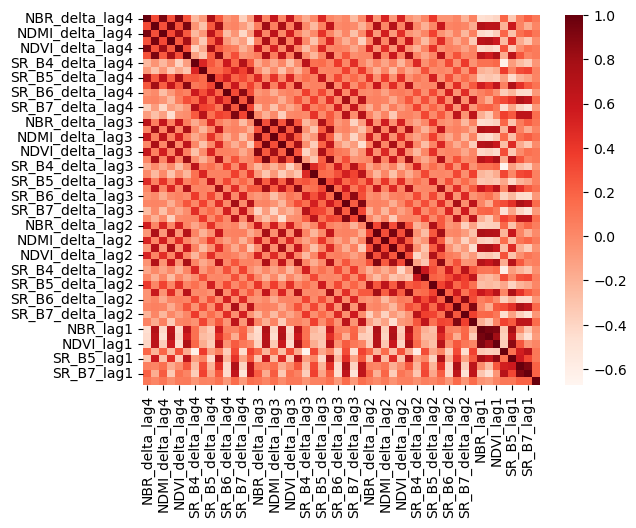

In [23]:
import seaborn as sns
sns.heatmap(pd.concat([amazon_train[all_features], amazon_train['class']], axis=1).corr(), cmap='Reds')
print(abs(pd.concat([amazon_train[all_features], amazon_train['class']], axis=1).corr()['class']).sort_values(ascending=False))

Features not well correlated...

# Compare Models

In [24]:
def custom_year_ts_split(df, year_col):
    """Custom CV splitter for our yearly data."""
    # Get unique years and sort them
    years = sorted(df[year_col].unique())
    
    # We need at least 2 years to do one split (Train Y1 -> Val Y2)
    for i in range(1, len(years)):
        # Training set: All years up to the current split
        train_indices = df[df[year_col].isin(years[:i])].index.values
        
        # Validation set: The very next year
        val_indices = df[df[year_col] == years[i]].index.values
        yield train_indices, val_indices

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_validate


## Logistic Regression

In [26]:

cv_iterator = custom_year_ts_split(train_set, 'year')
logistic_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', LogisticRegressionCV(
        cv=5, 
        l1_ratios=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], 
        max_iter=5000,
        solver='saga',
        random_state=1,
        use_legacy_attributes=False))])
logistic_results = cross_validate(
    logistic_pipe, 
    X_train, 
    y_train, 
    cv=cv_iterator, 
    return_estimator=True,
    scoring=['f1', 'precision', 'recall'], 
    return_train_score=True  # Crucial for detecting overfitting
)

/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/deforestationenv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.w

In [27]:
print(f"Mean Test f1: {logistic_results['test_f1'].mean():.4f}")
print(f"Mean Test Precision: {logistic_results['test_precision'].mean():.4f}")
print(f"Mean Test Recall: {logistic_results['test_recall'].mean():.4f}")

print(f"Mean Train f1: {logistic_results['train_f1'].mean():.4f}")
print(f"Mean Train Precision: {logistic_results['train_precision'].mean():.4f}")
print(f"Mean Train Recall: {logistic_results['train_recall'].mean():.4f}")

print(f"Overfitting Ratio: {1-logistic_results['test_f1'].mean()/logistic_results['train_f1'].mean()}")

Mean Test f1: 0.5925
Mean Test Precision: 0.6315
Mean Test Recall: 0.5582
Mean Train f1: 0.6188
Mean Train Precision: 0.6417
Mean Train Recall: 0.5975
Overfitting Ratio: 0.04243546040123036


Logistic Regression exhibits bad f1 scores with high overfitting.

## XGBoost

In [28]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

In [29]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer(1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [30]:
xgb_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))
])

tuner = BayesSearchCV(
    estimator=xgb_pipe,
    cv=5,
    n_iter=32,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1',
)

cv_iterator = custom_year_ts_split(train_set, 'year')

xgb_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [31]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(xgb_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_

    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {xgb_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {xgb_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {xgb_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {xgb_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {xgb_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {xgb_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-xgb_results['test_f1'].mean()/xgb_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__colsample_bylevel': 0.6580727264927247, 'model__colsample_bynode': 0.8694397068876266, 'model__max_depth': 5, 'model__min_child_weight': 110, 'model__reg_alpha': 6.3617453454390525, 'model__reg_lambda': 0.36544490062042084, 'model__subsample': 0.8477941757926019})
Outer Fold 1 - Inner Mean Test Score:  0.650492
Outer Fold 1 - Inner Test Score STD:  0.009912
Outer Fold 1 - Inner Mean Train Score: 0.739940
Outer Fold 1 - Inner Train Score STD:  0.009912
Outer Fold 2 Parameters - OrderedDict({'model__colsample_bylevel': 0.5942822710928165, 'model__colsample_bynode': 0.9299317238525302, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__reg_alpha': 5.422579084873314, 'model__reg_lambda': 5.798160173850929, 'model__subsample': 1.0})
Outer Fold 2 - Inner Mean Test Score:  0.651913
Outer Fold 2 - Inner Test Score STD:  0.005919
Outer Fold 2 - Inner Mean Train Score: 0.741456
Outer Fold 2 - Inner Train Score STD:  0.005919

Overall Metri

XGBoost outperforms Logistic Regression and SVC, but has more risk of overfitting, and f1 scores remain objectively low.

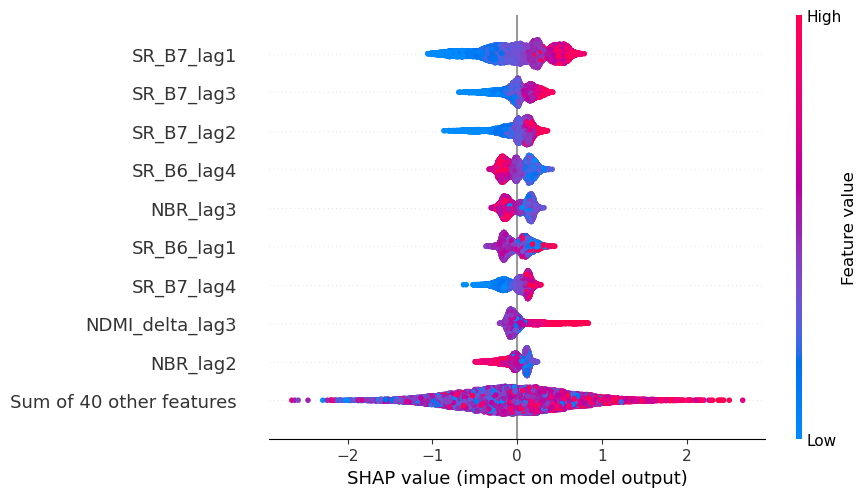

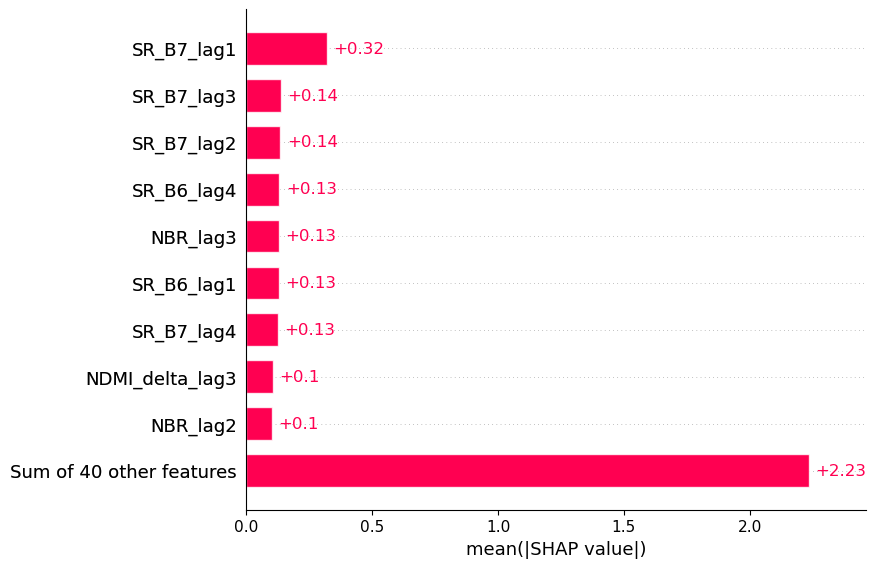

In [32]:
import shap
# Re-fit the tuner on full training data to get a final best estimator for interpretation
tuner.fit(X_train, y_train)
best_pipe = tuner.best_estimator_
model = best_pipe.named_steps['model']
explainer = shap.Explainer(model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    best_pipe.named_steps['transformer'].transform(X_train),
    columns=all_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


## SVC

In [33]:
from sklearn.svm import SVC

In [34]:
svc_param_grid = {
    'model__C': Real(0.1, 10),
    'model__kernel': Categorical(['linear', 'poly', 'rbf'])
}

In [35]:
svc_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', SVC(random_state=1))])

tuner = BayesSearchCV(
    estimator=svc_pipe,
    cv=5,
    n_iter=32,
    search_spaces=svc_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

cv_iterator = custom_year_ts_split(train_set, 'year')

svc_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [36]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(svc_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_
    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {svc_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {svc_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {svc_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {svc_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {svc_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {svc_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-svc_results['test_f1'].mean()/svc_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__C': 7.37201739872335, 'model__kernel': 'rbf'})
Outer Fold 1 - Inner Mean Test Score:  0.661280
Outer Fold 1 - Inner Test Score STD:  0.015728
Outer Fold 1 - Inner Mean Train Score: 0.761093
Outer Fold 1 - Inner Train Score STD:  0.015728
Outer Fold 2 Parameters - OrderedDict({'model__C': 3.858757211432233, 'model__kernel': 'rbf'})
Outer Fold 2 - Inner Mean Test Score:  0.654640
Outer Fold 2 - Inner Test Score STD:  0.013779
Outer Fold 2 - Inner Mean Train Score: 0.715375
Outer Fold 2 - Inner Train Score STD:  0.013779

Overall Metrics
Mean Test f1: 0.62528627
Mean Test Precision: 0.64425664
Mean Test Recall: 0.60746242
Mean Train f1: 0.73411600
Mean Train Precision: 0.72758057
Mean Train Recall: 0.74080416
Overfitting Ratio: 0.1482459551682126


SVC beats Logistic Regression, but loses to XGBoost, with strong overfitting.

## Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
rf_param_grid = {
    'model__max_depth': Integer(2, 12),
    'model__min_samples_split': Integer(2, 40),
    'model__min_samples_leaf': Integer(2, 40),
    'model__max_features': Real(0.1, 1),
}

In [39]:
rf_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', RandomForestClassifier(random_state=1))])

tuner=BayesSearchCV(estimator=rf_pipe, cv=5, refit='f1', search_spaces=rf_param_grid,
        return_train_score=True,
        random_state=1,
        scoring='f1')

cv_iterator = custom_year_ts_split(train_set, 'year')

rf_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [40]:
# # Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
# for outer_fold, outer_estimator in enumerate(rf_results['estimator'], start=1):
#     search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
#     inner_results = pd.DataFrame(search.cv_results_)
#     best_idx = search.best_index_
#     print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
#     mean_test = inner_results.loc[best_idx, "mean_test_score"]
#     std_test = inner_results.loc[best_idx, "std_test_score"]
#     print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
#     print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

#     if "mean_train_score" in inner_results.columns:
#         mean_train = inner_results.loc[best_idx, "mean_train_score"]
#         std_train = inner_results.loc[best_idx, "std_train_score"]
#         print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
#         print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_train:.6f}")
#     else:
#         print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {rf_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {rf_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {rf_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {rf_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {rf_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {rf_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-rf_results['test_f1'].mean()/rf_results['train_f1'].mean()}")


Overall Metrics
Mean Test f1: 0.61031597
Mean Test Precision: 0.63468152
Mean Test Recall: 0.58776006
Mean Train f1: 0.83780335
Mean Train Precision: 0.84289054
Mean Train Recall: 0.83280899
Overfitting Ratio: 0.2715283775687427


Random Forest wildly overfits.

# Observations
* All models do badly. Yay! 
    * The Landsat bands may not be useful in predicting deforestation--at least for a global model. 
* Precision > Recall.
* Best Model: XGBoost. But in general, classical ML seems to fail here.